# Modelo — CNN 1D **multi-label** con señal de 500 Hz

Clasificación **multi-etiqueta**: cada ECG puede asociarse a una o más de las 5 superclases (`NORM, MI, STTC, CD, HYP`).

**Diseño (multi-label):**

| | **multi-label (este)** | single-label |
|---|---|---|
| Etiqueta | **one-hot / multi-hot con varios 1** | un entero (la clase principal) |
| Salida | **sigmoide (5 independientes)** | softmax (5 que compiten) |
| Loss | **BCEWithLogitsLoss** (con pos_weight de clase) | CrossEntropyLoss (con pesos de clase) |
| Predicción | **umbral óptimo por clase** | argmax (exactamente 1) |
| Métrica ancla | **F1-macro** | accuracy (+ F1-macro secundaria) |

Señal a 500 Hz `(5000, 12)`. Split por paciente, normalización con stats de train.


## 1. Setup

In [41]:
import ast, os, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DATA = Path("..") / "data"
MODELS = Path("..") / "models"; MODELS.mkdir(exist_ok=True)
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
FS = 500          # frecuencia de muestreo
N_SAMPLES = 5000  # 10 s × 500 Hz

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.12.1 | device: mps


## 2. Metadata y split por paciente

Mismo split ~80/10/10 por `patient_id` (misma semilla que el notebook de 100 Hz → los conjuntos son los mismos pacientes, comparables).

In [42]:
df = pd.read_csv(DATA / "ptbxl_clean.csv", index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
df["diagnostic_superclass"] = df["diagnostic_superclass"].apply(ast.literal_eval)
print("ECGs:", len(df), "| columnas:", list(df.columns))

groups = df.patient_id.values
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
tv_idx, test_idx = next(gss1.split(df, groups=groups))
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.111, random_state=SEED)
tr_rel, val_rel = next(gss2.split(df.iloc[tv_idx], groups=groups[tv_idx]))
train_idx = tv_idx[tr_rel]
val_idx = tv_idx[val_rel]

s_tr, s_val, s_te = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (s_tr & s_val) and not (s_tr & s_te) and not (s_val & s_te), "fuga de pacientes!"
print(f"train {len(train_idx):,} | val {len(val_idx):,} | test {len(test_idx):,}  (sin fuga)")
print(f"pacientes -> train {len(s_tr):,} | val {len(s_val):,} | test {len(s_te):,}")

ECGs: 21430 | columnas: ['patient_id', 'age', 'sex', 'scp_codes', 'filename_lr', 'filename_hr', 'diagnostic_superclass', 'n_superclass', 'NORM', 'MI', 'STTC', 'CD', 'HYP']
train 17,137 | val 2,180 | test 2,113  (sin fuga)
pacientes -> train 14,911 | val 1,862 | test 1,864


## 3. Señales 500 Hz (caché en memoria)

Carga desde `data/records500` (vía `filename_hr`) a un array `(N, 5000, 12)` y lo guarda en `data/X_500hz.npy` (~5.1 GB). En ejecuciones siguientes lee el caché.

⚠️ La primera ejecución descarga ~5 GB a disco y a RAM. Si tu memoria es limitada, considera usar el notebook de 100 Hz o procesar por lotes.

In [43]:
cache = DATA / "X_500hz.npy"
if cache.exists():
    X = np.load(cache, mmap_mode=None)
    ids = np.load(DATA / "ecg_ids_500.npy")
    assert np.array_equal(ids, df.index.values), "el caché no coincide con el CSV"
    print("caché cargado:", X.shape, f"({X.nbytes/1e9:.2f} GB en RAM)")
else:
    import wfdb
    X = np.zeros((len(df), N_SAMPLES, 12), dtype=np.float32)
    t = time.time()
    for i, f in enumerate(tqdm(df.filename_hr.values, desc="cargando señales 500 Hz")):
        sig, _ = wfdb.rdsamp(str(DATA / f))
        X[i] = sig.astype(np.float32)
    np.save(cache, X); np.save(DATA / "ecg_ids_500.npy", df.index.values)
    print(f"caché creado: {X.shape} en {time.time()-t:.0f}s ({cache.stat().st_size/1e9:.2f} GB)")

# estado de la señal CRUDA (antes de cualquier preprocesamiento)
print(f"  dtype: {X.dtype} | memoria: {X.nbytes/1e9:.2f} GB")
print(f"  señal cruda (mV) -> min {X.min():.2f}  max {X.max():.2f}  media {X.mean():.4f}  std {X.std():.3f}")
print("  ejemplo X[0], primeras 3 muestras × 12 derivaciones (mV):")
print(np.round(X[0, :3], 3))

caché cargado: (21430, 5000, 12) (5.14 GB en RAM)
  dtype: float32 | memoria: 5.14 GB
  señal cruda (mV) -> min -32.69  max 32.72  media -0.0008  std 0.236
  ejemplo X[0], primeras 3 muestras × 12 derivaciones (mV):
[[-0.115 -0.05   0.065  0.082 -0.09   0.007 -0.065 -0.04  -0.005 -0.035
  -0.035 -0.075]
 [-0.115 -0.05   0.065  0.082 -0.09   0.007 -0.065 -0.04  -0.005 -0.035
  -0.035 -0.075]
 [-0.115 -0.05   0.065  0.082 -0.09   0.007 -0.065 -0.04  -0.005 -0.035
  -0.035 -0.075]]


## 4. Preprocesamiento

Igual que en 100 Hz: z-score **por derivación** con stats de train, edad imputada+normalizada, sexo 0/1, etiquetas one-hot. La normalización de la señal se hace **in-place** para no duplicar 5 GB en memoria.

In [44]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# ===== SEÑAL: z-score por derivación (stats de train), normalización IN-PLACE =====
mean = X[train_idx].mean(axis=(0, 1), keepdims=True)   # (1,1,12)
std = X[train_idx].std(axis=(0, 1), keepdims=True) + 1e-6
print("Stats por derivación ANTES de normalizar (train, mV):")
print(pd.DataFrame({"mean_mV": mean.ravel().round(3), "std_mV": std.ravel().round(3)}, index=LEADS).T)

X -= mean        # in-place: evita copiar 5 GB
X /= std

print("\nStats por derivación DESPUÉS de normalizar (train):")
print(pd.DataFrame({"mean": X[train_idx].mean(axis=(0, 1)).round(3),
                    "std":  X[train_idx].std(axis=(0, 1)).round(3)}, index=LEADS).T)
print(f"-> global: media~{X[train_idx].mean():.3f}  std~{X[train_idx].std():.3f}  (objetivo: 0 y 1)")

# ===== EDAD: imputar NaN (mediana train) + z-score =====
age = df.age.values.astype(np.float32)
n_nan = int(np.isnan(age).sum())
age_median = np.nanmedian(age[train_idx])
print(f"\nEdad ANTES : rango {np.nanmin(age):.0f}–{np.nanmax(age):.0f}, mediana(train) {age_median:.0f}, NaN a imputar: {n_nan}")
age = np.where(np.isnan(age), age_median, age)
a_mean, a_std = age[train_idx].mean(), age[train_idx].std() + 1e-6
age_z = (age - a_mean) / a_std
print(f"Edad DESPUÉS: rango {age_z.min():.2f}–{age_z.max():.2f}, media(train)~{age_z[train_idx].mean():.3f}, std~{age_z[train_idx].std():.3f}, NaN: {int(np.isnan(age_z).sum())}")

# ===== SEXO: ya es 0/1 =====
sex = df.sex.values.astype(np.float32)
print(f"\nSexo (0=H, 1=M): {pd.Series(sex).value_counts().to_dict()}  -> sin transformación")

META = np.stack([age_z, sex], axis=1).astype(np.float32)  # (N,2)

# ===== ETIQUETA: multi-label =====
y = df[CLASSES].values.astype(np.float32)   # (N, 5) float32 for multi-label

print("\nEtiquetas multi-label -> distribución por split:")
for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
    cnt = y[idx].sum(axis=0).astype(int)
    print(f"  {name:5s}: " + "  ".join(f"{c}={n}" for c, n in zip(CLASSES, cnt)))
print("ejemplo y[0]:", y[0])

print(f"\nArrays finales -> X:{X.shape} {X.dtype} | META:{META.shape} {META.dtype} | y:{y.shape} {y.dtype}")

Stats por derivación ANTES de normalizar (train, mV):
             I     II    III    aVR    aVL    aVF     V1     V2     V3     V4  \
mean_mV -0.002 -0.001  0.001  0.002 -0.001 -0.000  0.000 -0.001 -0.002 -0.001   
std_mV   0.187  0.147  0.165  0.131  0.148  0.133  0.223  0.317  0.311  0.275   

            V5     V6  
mean_mV -0.001 -0.001  
std_mV   0.277  0.231  

Stats por derivación DESPUÉS de normalizar (train):
        I     II  III    aVR    aVL    aVF     V1     V2     V3   V4   V5  \
mean  0.0 -0.000 -0.0  0.000  0.000 -0.000  0.000 -0.000 -0.000 -0.0 -0.0   
std   1.0  0.998  1.0  1.001  0.996  1.001  0.998  0.997  0.995  1.0  1.0   

         V6  
mean -0.000  
std   0.999  
-> global: media~0.000  std~1.068  (objetivo: 0 y 1)

Edad ANTES : rango 2–95, mediana(train) 62, NaN a imputar: 85
Edad DESPUÉS: rango -3.39–2.08, media(train)~-0.000, std~1.000, NaN: 0

Sexo (0=H, 1=M): {0.0: 11137, 1.0: 10293}  -> sin transformación

Etiquetas multi-label -> distribución por split:


## 5. Dataset y DataLoaders

`BATCH = 64` (más chico que en 100 Hz porque cada muestra es 5× más larga en GPU).

In [45]:
class ECGDataset(Dataset):
    def __init__(self, idx):
        self.idx = idx
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        sig = torch.from_numpy(np.ascontiguousarray(X[j].T))  # (12, 5000)
        meta = torch.from_numpy(META[j])                       # (2,)
        label = torch.tensor(y[j], dtype=torch.float32)        # vector float (multi-label)
        return sig, meta, label

BATCH = 64
train_dl = DataLoader(ECGDataset(train_idx), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(ECGDataset(val_idx),   batch_size=BATCH)
test_dl  = DataLoader(ECGDataset(test_idx),  batch_size=BATCH)

print(f"tamaños -> train {len(train_dl.dataset):,} | val {len(val_dl.dataset):,} | test {len(test_dl.dataset):,}")
print(f"batch_size {BATCH} -> batches/época: train {len(train_dl)}, val {len(val_dl)}, test {len(test_dl)}")

sig, meta, yb = next(iter(train_dl))
print("\nun batch:")
print(f"  sig  {tuple(sig.shape)}  {sig.dtype}   (B, derivaciones, tiempo)")
print(f"  meta {tuple(meta.shape)}  {meta.dtype}")
print(f"  yb   {tuple(yb.shape)}  {yb.dtype}   (etiquetas multi-hot)")
print("  ejemplo yb[:4]:\n", yb[:4].numpy())


tamaños -> train 17,137 | val 2,180 | test 2,113
batch_size 64 -> batches/época: train 268, val 35, test 34

un batch:
  sig  (64, 12, 5000)  torch.float32   (B, derivaciones, tiempo)
  meta (64, 2)  torch.float32
  yb   (64, 5)  torch.float32   (etiquetas multi-hot)
  ejemplo yb[:4]:
 [[1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 1. 1. 1.]
 [1. 0. 0. 0. 0.]]


## 6. Modelo: CNN 1D de dos ramas (adaptada a 500 Hz)

Con 5000 muestras (5× más) usamos **kernels más grandes** y **un bloque conv extra**, para que cada filtro abarque una duración física comparable a la de 100 Hz y para reducir la longitud antes del pooling global. El resto (rama metadata + cabeza densa) es idéntico.

In [46]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k, pool=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c_in, c_out, k, padding=k // 2),
            nn.BatchNorm1d(c_out),
            nn.ReLU(),
            nn.MaxPool1d(pool),
        )
    def forward(self, x):
        return self.net(x)

class ECGNet500(nn.Module):
    def __init__(self, n_leads=12, n_meta=2, n_classes=5, use_meta=True):
        super().__init__()
        self.use_meta = use_meta
        # 5000 -> 1250 -> 312 -> 78 -> 39 -> AdaptiveAvgPool
        self.cnn = nn.Sequential(
            ConvBlock(n_leads, 64, 15, pool=4),   # kernel grande: ~30 ms
            ConvBlock(64, 128, 11, pool=4),
            ConvBlock(128, 256, 7, pool=4),
            ConvBlock(256, 256, 5, pool=2),
            nn.AdaptiveAvgPool1d(1),
        )
        head_in = 256 + (n_meta if use_meta else 0)
        self.head = nn.Sequential(
            nn.Linear(head_in, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )
    def forward(self, sig, meta):
        x = self.cnn(sig).flatten(1)
        if self.use_meta:
            x = torch.cat([x, meta], dim=1)
        return self.head(x)

model = ECGNet500(use_meta=True).to(device)
print(model)
print(f"\nparámetros entrenables: {sum(p.numel() for p in model.parameters()):,}")

ECGNet500(
  (cnn): Sequential(
    (0): ConvBlock(
      (net): Sequential(
        (0): Conv1d(12, 64, kernel_size=(15,), stride=(1,), padding=(7,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (net): Sequential(
        (0): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (net): Sequential(
        (0): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(3,))
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_s

## 7. Loss, optimizador y métricas

`CrossEntropyLoss` (softmax + log-loss, asume **una clase correcta** por ECG) con **pesos de clase** = inverso de frecuencia, para compensar el desbalance. Métrica **ancla**: **accuracy** (selecciona el mejor modelo); F1-macro se reporta como secundaria.

> Nota: con pesos de clase en la loss y accuracy como ancla hay una leve tensión (los pesos favorecen clases raras, la accuracy favorece la mayoritaria NORM). Es intencional según tu elección de ancla.

In [47]:
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, multilabel_confusion_matrix

# Calculemos pos_weight = (N_neg) / (N_pos) para cada clase en train para balancear
pos_counts = y[train_idx].sum(axis=0)
neg_counts = len(train_idx) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32, device=device)
print("conteo train por clase (positivos):", dict(zip(CLASSES, pos_counts.astype(int))))
print("pos_weight:        ", dict(zip(CLASSES, pos_weight.cpu().numpy().round(2))))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

@torch.no_grad()
def evaluate(dl):
    """Devuelve (loss, f1_macro, probs, trues). Métrica ancla: f1_macro."""
    model.eval()
    logits_all, trues, loss_sum, n = [], [], 0.0, 0
    for sig, meta, yb in dl:
        sig, meta, yb = sig.to(device), meta.to(device), yb.to(device)
        logits = model(sig, meta)
        loss_sum += criterion(logits, yb).item() * len(yb); n += len(yb)
        logits_all.append(logits.cpu().numpy())
        trues.append(yb.cpu().numpy())
    logits_all = np.concatenate(logits_all); trues = np.concatenate(trues)
    probs = 1 / (1 + np.exp(-logits_all)) # Sigmoid activation
    preds = (probs >= 0.5).astype(int)
    f1_macro = f1_score(trues, preds, average="macro", zero_division=0)
    return loss_sum / n, f1_macro, probs, trues


conteo train por clase (positivos): {'NORM': np.int64(7634), 'MI': np.int64(4388), 'STTC': np.int64(4164), 'CD': np.int64(3897), 'HYP': np.int64(2093)}
pos_weight:         {'NORM': np.float32(1.24), 'MI': np.float32(2.91), 'STTC': np.float32(3.12), 'CD': np.float32(3.4), 'HYP': np.float32(7.19)}


## 8. Entrenamiento

Cada época es más lenta que en 100 Hz (secuencias 5× más largas). Guarda el mejor modelo por **val accuracy** en `models/ecgnet500_singlelabel_best.pt`.

In [ ]:
EPOCHS = 20
history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, best_path = 0.0, MODELS / "ecgnet500_best.pt"

for epoch in range(1, EPOCHS + 1):
    model.train()
    run, n = 0.0, 0
    for sig, meta, yb in tqdm(train_dl, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
        sig, meta, yb = sig.to(device), meta.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(sig, meta), yb)
        loss.backward(); optimizer.step()
        run += loss.item() * len(yb); n += len(yb)
    tr_loss = run / n
    val_loss, val_f1, _, _ = evaluate(val_dl)
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    flag = ""
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), best_path)
        flag = "  <- guardado (best)"
    print(f"epoch {epoch:2d} | train_loss {tr_loss:.4f} | val_loss {val_loss:.4f} | val_f1 {val_f1:.4f}{flag}")

print(f"\nMejor val F1-macro: {best_f1:.4f}  ->  {best_path}")

epoch 1/20:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  1 | train_loss 0.6519 | val_loss 0.6236 | val_f1 0.6377  <- guardado (best)


epoch 2/20:   0%|          | 0/268 [00:00<?, ?it/s]

epoch  2 | train_loss 0.5600 | val_loss 0.5766 | val_f1 0.7211  <- guardado (best)


epoch 3/20:   0%|          | 0/268 [00:00<?, ?it/s]

...

epoch 18 | train_loss 0.4209 | val_loss 0.5093 | val_f1 0.7627  <- guardado (best)


epoch 19/20:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 19 | train_loss 0.4100 | val_loss 0.5038 | val_f1 0.7428


epoch 20/20:   0%|          | 0/268 [00:00<?, ?it/s]

epoch 20 | train_loss 0.4075 | val_loss 0.4940 | val_f1 0.7414

Mejor val F1-macro: 0.7627  ->  ../models/ecgnet500_multilabel_best.pt


## 9. Curvas de entrenamiento

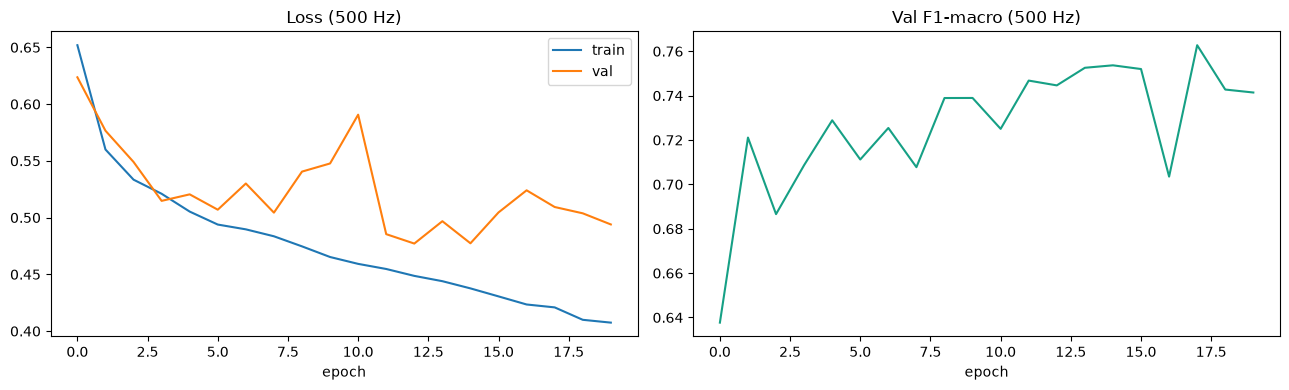

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss (500 Hz)"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].plot(history["val_f1"], color="#16a085")
axes[1].set_title("Val F1-macro (500 Hz)"); axes[1].set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 10. Evaluación en test

Reportamos **accuracy** (métrica ancla) y **F1-macro** (secundaria), más el detalle de **precision/recall/F1 por clase**. La matriz de confusión va en la sección 11.

In [50]:
# 1. Cargar el mejor modelo
model.load_state_dict(torch.load(best_path, map_location=device))

# 2. Evaluar en validación para encontrar los umbrales óptimos
_, _, val_probs, val_trues = evaluate(val_dl)

def find_optimal_thresholds(y_true, y_probs, num_classes=5):
    thresholds = np.zeros(num_classes)
    for c in range(num_classes):
        best_threshold = 0.5
        best_f1 = 0.0
        for threshold in np.arange(0.01, 1.0, 0.01):
            preds = (y_probs[:, c] >= threshold).astype(int)
            f1 = f1_score(y_true[:, c], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        thresholds[c] = best_threshold
    return thresholds

optimal_thresholds = find_optimal_thresholds(val_trues, val_probs)
print("Umbrales óptimos por clase (en validación):")
for c, name in enumerate(CLASSES):
    print(f"  {name}: {optimal_thresholds[c]:.2f}")
print()

# 3. Evaluar en test
test_loss, _, test_probs, test_trues = evaluate(test_dl)

# Aplicar los umbrales óptimos para obtener las predicciones finales en test
test_preds = (test_probs >= optimal_thresholds).astype(int)

# Calcular métricas macro y micro en test
test_f1_macro = f1_score(test_trues, test_preds, average="macro", zero_division=0)
test_f1_micro = f1_score(test_trues, test_preds, average="micro", zero_division=0)

print(f"TEST 500 Hz  F1-macro (con umbrales óptimos): {test_f1_macro:.4f}  |  F1-micro: {test_f1_micro:.4f}  |  loss: {test_loss:.4f}\n")

# Mostrar classification report
from sklearn.metrics import classification_report
print("Classification Report (en test):")
print(classification_report(test_trues, test_preds, target_names=CLASSES, zero_division=0))

Umbrales óptimos por clase (en validación):
  NORM: 0.49
  MI: 0.68
  STTC: 0.56
  CD: 0.82
  HYP: 0.70

TEST 500 Hz  F1-macro (con umbrales óptimos): 0.7670  |  F1-micro: 0.7920  |  loss: 0.5487

Classification Report (en test):
              precision    recall  f1-score   support

        NORM       0.83      0.91      0.87       940
          MI       0.78      0.73      0.76       528
        STTC       0.70      0.80      0.75       526
          CD       0.85      0.75      0.80       494
         HYP       0.71      0.63      0.67       283

   micro avg       0.79      0.80      0.79      2771
   macro avg       0.78      0.76      0.77      2771
weighted avg       0.79      0.80      0.79      2771
 samples avg       0.80      0.82      0.79      2771



## 11. Matrices de confusión por clase (Per-class Confusion Matrices)

Al ser multi-label, la matriz de confusión clásica de 5×5 no aplica. En su lugar, mostramos la matriz de confusión binaria de 2×2 para cada una de las 5 clases (Negativo vs. Positivo).

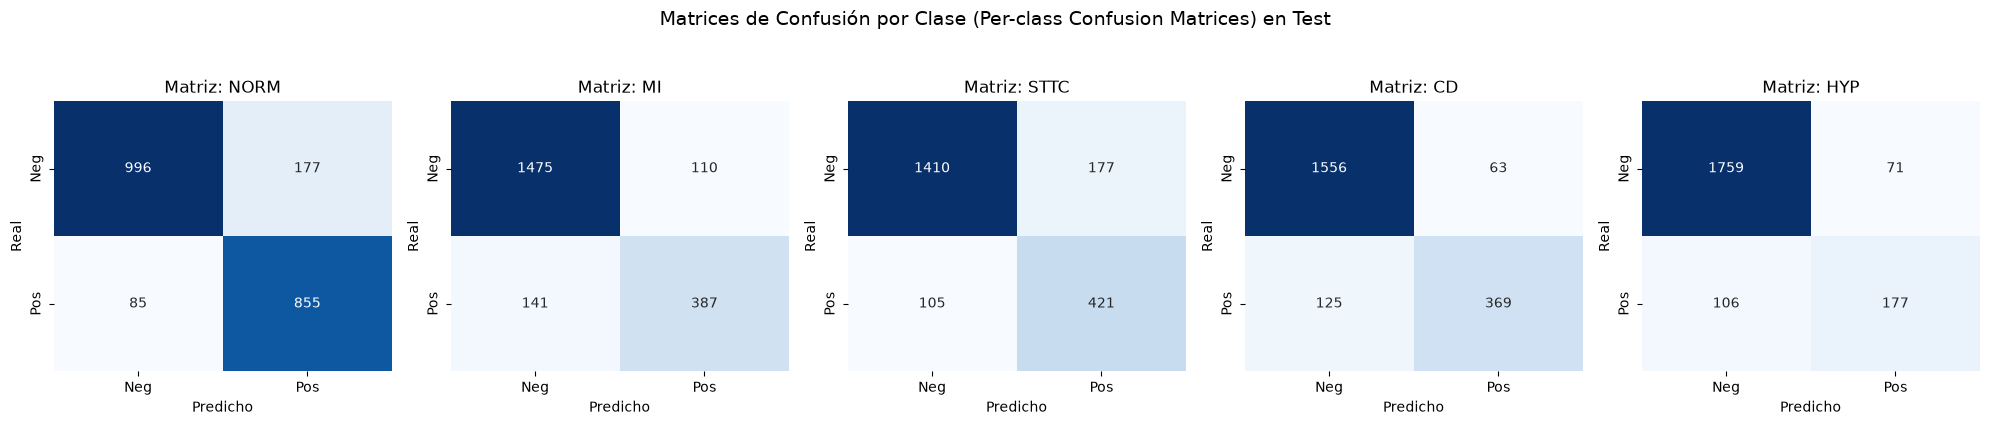

In [54]:
from sklearn.metrics import multilabel_confusion_matrix

# Obtener matrices de confusión por clase (2x2: [TN, FP], [FN, TP])
mcm = multilabel_confusion_matrix(test_trues, test_preds)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(20, 4))
for c, name in enumerate(CLASSES):
    sns.heatmap(mcm[c], annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=axes[c])
    axes[c].set_xlabel("Predicho")
    axes[c].set_ylabel("Real")
    axes[c].set_title(f"Matriz: {name}")

plt.suptitle("Matrices de Confusión por Clase (Per-class Confusion Matrices) en Test", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 12. ¿Qué aprendieron los filtros?

La 1ª convolución tiene **64 filtros**, cada uno de forma `(12 derivaciones × 15 muestras)`. Los visualizamos de dos maneras: como **heatmaps** (qué derivaciones y qué instantes activa cada filtro) y como **formas de onda** (el patrón temporal que busca cada uno). Son el equivalente 1D a los detectores de bordes de una CNN de imágenes: detectan pendientes, oscilaciones y derivadas de la señal.

pesos 1ª conv: (64, 12, 15) (filtros, derivaciones, muestras del kernel)


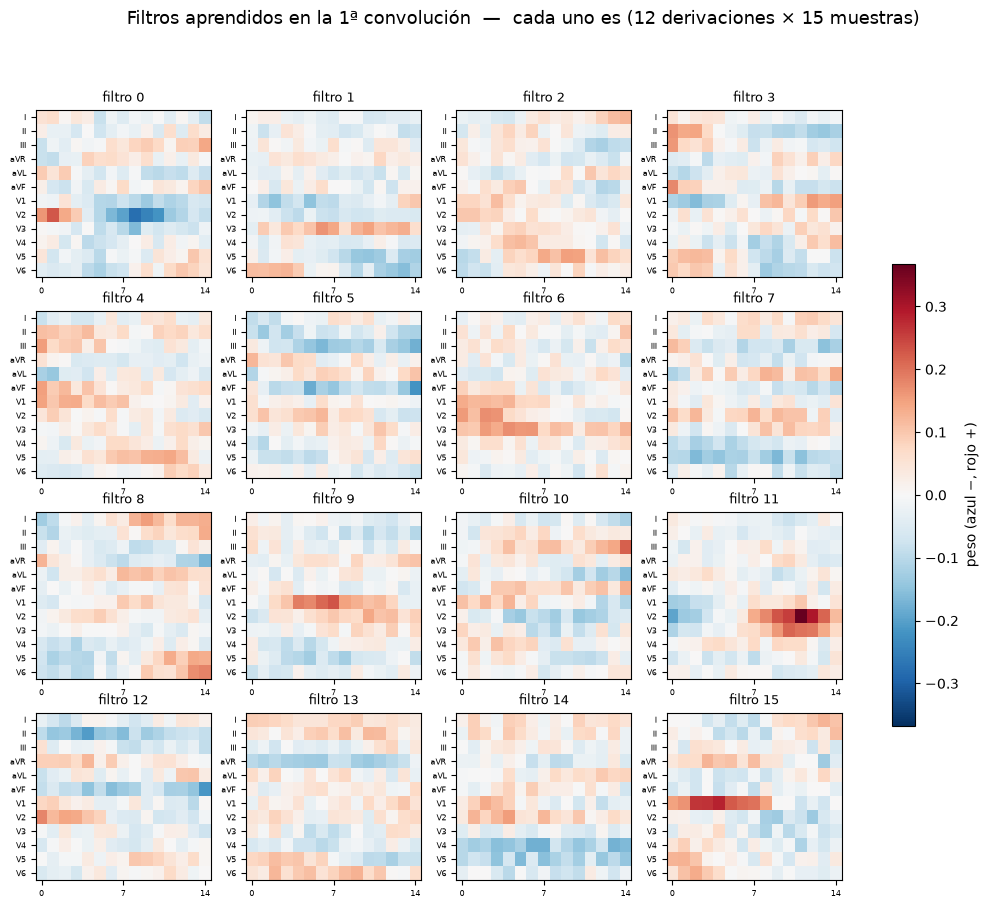

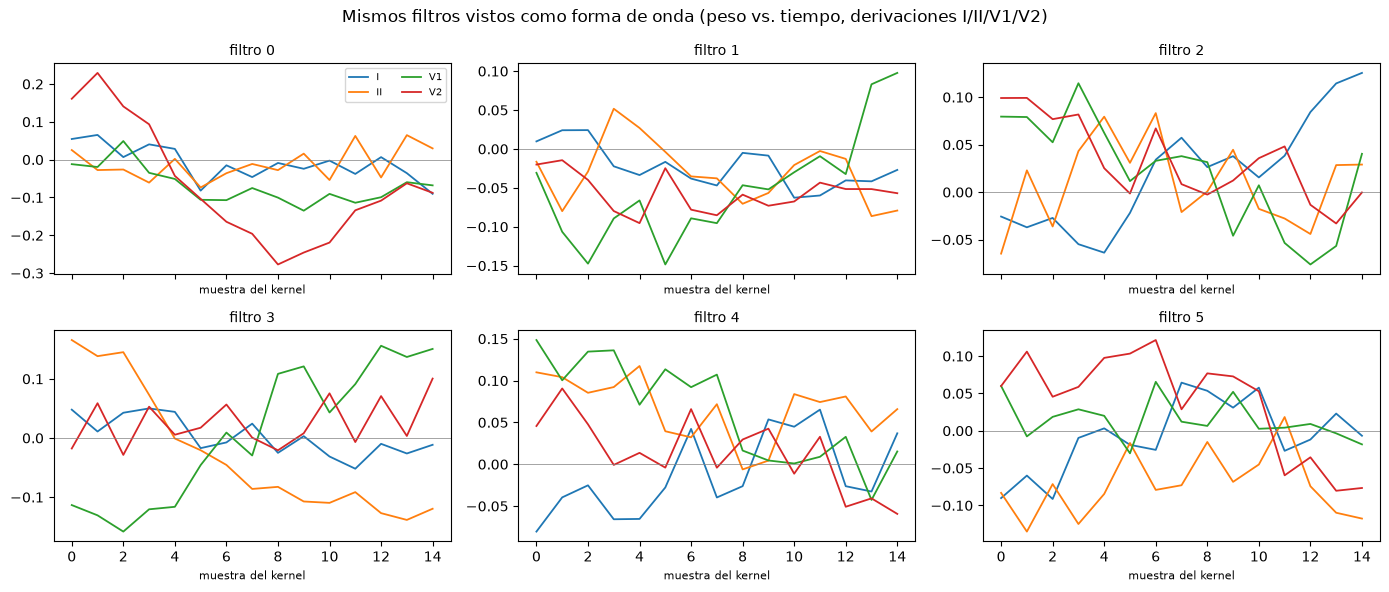

In [52]:
# pesos de la 1ª convolución: (n_filtros, n_derivaciones, kernel)
w = model.cnn[0].net[0].weight.detach().cpu().numpy()
print("pesos 1ª conv:", w.shape, "(filtros, derivaciones, muestras del kernel)")

# A) 16 filtros como heatmaps (derivaciones × tiempo del kernel)
n_show = 16
vmax = np.abs(w[:n_show]).max()
fig, axes = plt.subplots(4, 4, figsize=(13, 10))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(w[i], aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"filtro {i}", fontsize=9)
    ax.set_yticks(range(12)); ax.set_yticklabels(LEADS, fontsize=6)
    ax.set_xticks([0, 7, 14]); ax.tick_params(labelsize=6)
fig.colorbar(im, ax=axes, shrink=0.6, label="peso (azul −, rojo +)")
fig.suptitle("Filtros aprendidos en la 1ª convolución  —  cada uno es (12 derivaciones × 15 muestras)", fontsize=13)
plt.show()

# B) algunos filtros como forma de onda (peso a lo largo del kernel, por derivación clave)
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for ax, fi in zip(axes.flat, [0, 1, 2, 3, 4, 5]):
    for li in [0, 1, 6, 7]:  # I, II, V1, V2
        ax.plot(w[fi, li], lw=1.3, label=LEADS[li])
    ax.set_title(f"filtro {fi}", fontsize=10); ax.axhline(0, color="gray", lw=0.5)
    ax.set_xlabel("muestra del kernel", fontsize=8)
axes[0, 0].legend(fontsize=7, ncol=2)
fig.suptitle("Mismos filtros vistos como forma de onda (peso vs. tiempo, derivaciones I/II/V1/V2)", fontsize=12)
plt.tight_layout()
plt.show()

## 13. Grad-CAM 1D: ¿dónde mira la red? (un ejemplo por clase)

Para "abrir la caja negra", implementamos **Grad-CAM 1D** en PyTorch. Usamos hooks para capturar las activaciones y gradientes de la **última capa convolucional** (que tiene los patrones más complejos antes del pooling global).

Para cada una de las 5 clases, elegimos el ECG de test en el que el modelo predijo esa clase con **mayor confianza (probabilidad sigmoid)**. Graficamos la derivación II (en negro) y superponemos el heatmap de importancia Grad-CAM (en colores cálidos: rojo/amarillo es donde más miró la red) con respecto a esa clase.

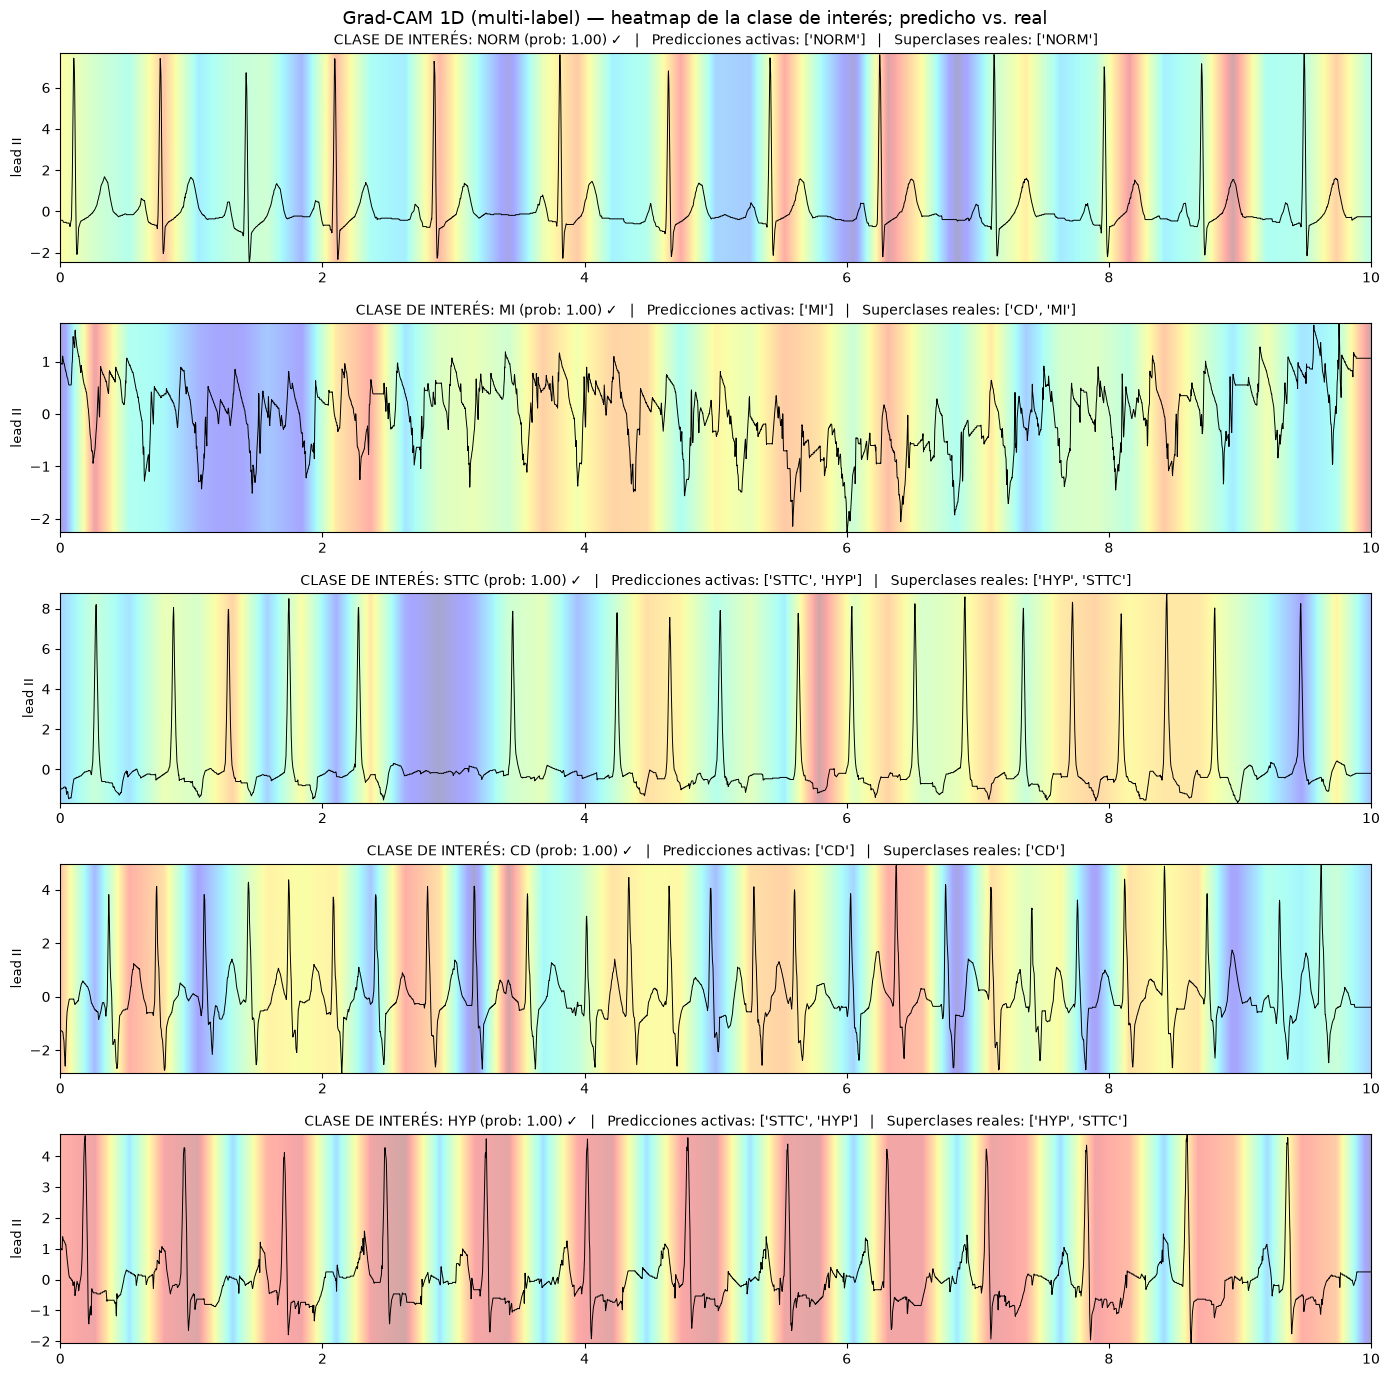

In [53]:
# ===== 1) elegir el ejemplo MÁS confiado de cada clase (por su clase principal real) =====
@torch.no_grad()
def predict_all(idx):
    model.eval()
    out = []
    for i in range(0, len(idx), 64):
        b = idx[i:i + 64]
        sig = torch.from_numpy(np.ascontiguousarray(X[b].transpose(0, 2, 1))).to(device)
        meta = torch.from_numpy(META[b]).to(device)
        out.append(torch.sigmoid(model(sig, meta)).cpu().numpy())   # sigmoid (multi-label)
    return np.concatenate(out)

test_probs = predict_all(test_idx)        # (n, 5) probabilidades sigmoid
test_true = y[test_idx]                    # (n, 5) etiquetas reales multi-label
examples, example_probs = {}, {}
for c, name in enumerate(CLASSES):
    cand = np.where(test_true[:, c] == 1)[0]                 # ECGs que tienen la clase c
    best = cand[np.argmax(test_probs[cand, c])]         # el predicho con más confianza
    examples[name] = int(test_idx[best])
    example_probs[name] = test_probs[best]

# ===== 2) Grad-CAM 1D sobre la última convolución (model.cnn[3]) =====
acts, grads = {}, {}
def _fwd_hook(m, i, o):
    acts["v"] = o
    if o.requires_grad:
        o.register_hook(lambda g: grads.__setitem__("v", g))
handle = model.cnn[3].register_forward_hook(_fwd_hook)

def grad_cam(pos_idx, target_class):
    model.eval()
    sig = torch.from_numpy(np.ascontiguousarray(X[pos_idx].T)[None]).to(device)
    meta = torch.from_numpy(META[pos_idx][None]).to(device)
    model.zero_grad()
    logits = model(sig, meta)
    logits[0, target_class].backward()
    a = acts["v"][0]; g = grads["v"][0]
    w = g.mean(dim=1)
    cam = torch.relu((w[:, None] * a).sum(0)).detach().cpu().numpy()
    cam = np.interp(np.arange(5000), np.linspace(0, 4999, len(cam)), cam)
    cam = (cam - cam.min()) / (np.ptp(cam) + 1e-8)
    return cam

# ===== 3) graficar: lead II + heatmap, predicho vs real =====
t = np.arange(5000) / FS
LEAD = 1
fig, axes = plt.subplots(len(CLASSES), 1, figsize=(14, 14))
for ax, (name, pos) in zip(axes, examples.items()):
    p = example_probs[name]
    target_idx = CLASSES.index(name)
    cam = grad_cam(pos, target_idx)                        # heatmap de la clase de interés
    s = X[pos][:, LEAD]
    ax.imshow(cam[None, :], aspect="auto", cmap="jet", alpha=0.35,
              extent=[0, 10, s.min(), s.max()], origin="lower")
    ax.plot(t, s, color="black", lw=0.7)
    ax.set_xlim(0, 10); ax.set_ylim(s.min(), s.max())
    ax.set_ylabel("lead II", fontsize=9)
    real_super = df.loc[df.index[pos], "diagnostic_superclass"]
    
    pred_val = 1 if p[target_idx] >= optimal_thresholds[target_idx] else 0
    ok = "✓" if pred_val == 1 else "✗"
    all_preds = [CLASSES[i] for i in range(len(CLASSES)) if p[i] >= optimal_thresholds[i]]
    
    ax.set_title(f"CLASE DE INTERÉS: {name} (prob: {p[target_idx]:.2f}) {ok}   |   "
                 f"Predicciones activas: {all_preds}   |   "
                 f"Superclases reales: {real_super}", fontsize=10)
fig.suptitle("Grad-CAM 1D (multi-label) — heatmap de la clase de interés; predicho vs. real", fontsize=13)
handle.remove()
plt.tight_layout()
plt.show()